# Denoising Diffusion Probabilistic Models

This notebook is a minimalistic implementation of the [Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239) paper.  The paper has been used to great effect for generating realistic images while also avoiding the mode collapse problems often seen in GANs.  To keep things simple we will be using the MNIST dataset. The method involves training a CNN to predict the noise component in a partially corrupted image.  At inference time we apply this CNN to pure white noise, the predicted noise component is subtracted from the input, renoised, and the result is feed into the network again.  We repeat this for a large number of steps (the original paper uses 1000) to generate a new image modelled after the training data. The CNN architecure is somewhat arbitrary, but following the paper we will use a modified version of a U-Net.


## Setup

Firstly, let's import our libraries and define other useful stuff.

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import diffusers
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

In [2]:
# Are we on GPU or CPU?
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset

Now, let download our dataset. For this notebook we will use the MNIST dataset of handwriten digits.

In [3]:
# Define batch size
bs = 64

# Define transforms for the images
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Download the training data
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=bs, shuffle=True)

# Download the test dataset
dataset_val = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
dataloader_val = DataLoader(dataset, batch_size=bs, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 487kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.2MB/s]


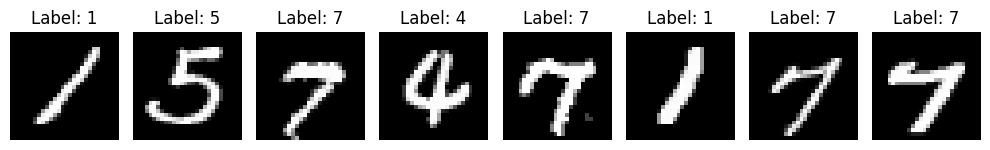

In [4]:
# Get a batch of images
images, labels = next(iter(dataloader))

# Display batch of images
fig, axes = plt.subplots(1, 8, figsize=(10, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.axis('off')
    ax.set_title(f'Label: {labels[i].item()}')
plt.tight_layout()
plt.show()

## Model

The neural network architectures we will use is a UNet with three downsampling blocks and three upsampling blocks. We will creates this network using the diffusers library and you can change its archicture via the config variable. For example, you change the depth of the network using the layers_per_block option, which controls the number of layer for each of the up/down blocks.

This exact architecture is also commonly used for diffusion models.  Here is an example of UNet architecture, this diagram differs from our architecture in some ways, but the general structure is the same.

<img src="https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png" width="540">

In [5]:
# Initialize model and do some training
def create_unet():
    model = diffusers.UNet2DModel(
        sample_size=28,          # input image size
        in_channels=1,           # grayscale input
        out_channels=1,          # grayscale output
        block_out_channels=(64, 64, 128),
        down_block_types=("DownBlock2D", "AttnDownBlock2D", "DownBlock2D"),
        up_block_types=("UpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
        num_class_embeds=11,
    ).to(device)
    return model

## Noise Schedule

How do we add noise to these MNIST images?  Over $T=1000$ time steps $t$, we gradually add Gaussian noise. We call this the forward process and model it using $q(x_t|x_{t-1})$ where $x_t$ is an image at time step $t$.  So at time $x_0$ we have an MNIST image uncorrupted by noise, at $x_{483}$ we have an MNIST image that is mixed with noise, and at $x_{1000}$ we have pure noise.

To add this noise we will use a linear schedule controlled by parameter $\beta=0.0001...0.02$

$$ q(x_t|x_{t-1})=\mathcal{N}(\sqrt{1-\beta_t}x_{t-1}, \beta_t\boldsymbol{I})$$

However, we have a problem.  To calculate $x_{1000}$ would would need to apply this formular recursivly 1000 times!  So to simplify this we can rewrite it as

$$ q(x_t|x_0)=\mathcal{N}(\sqrt{\bar{\alpha_t}}x_0, (1-\bar{\alpha_t})\boldsymbol{I})$$

where
$$\alpha_t=1-\beta_t$$
$$\bar{\alpha_t}=\prod_{s=1}^t{\alpha_s}$$

These values are computed below and will be very important during both training sampling.

In [6]:
# Noise schedule
beta_start = 0.0001
beta_end = 0.02
timesteps = 1000
betas = torch.linspace(beta_start, beta_end, timesteps).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)

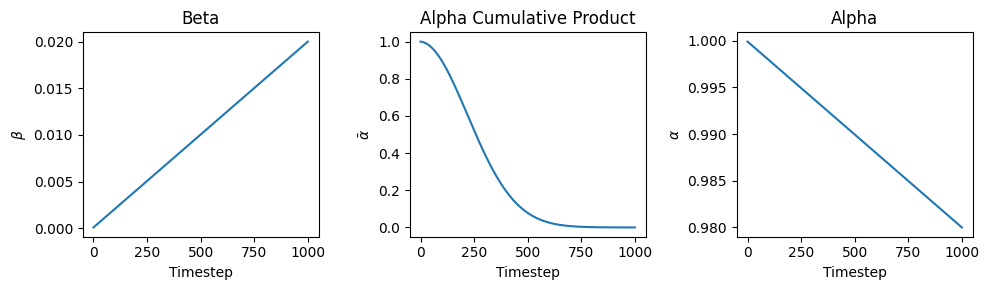

In [7]:
# Display noise schedule values
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 3))

ax1.plot(betas.cpu().numpy())
ax1.set_xlabel("Timestep")
ax1.set_title("Beta")
ax1.set_ylabel(r'$\beta$')

ax2.plot(alphas_cumprod.cpu().numpy())
ax2.set_xlabel("Timestep")
ax2.set_title("Alpha Cumulative Product")
ax2.set_ylabel(r'$\bar{\alpha}$')

ax3.plot(alphas.cpu().numpy())
ax3.set_xlabel("Timestep")
ax3.set_title("Alpha")
ax3.set_ylabel(r'$\alpha$')

plt.tight_layout()

## Sampling

Here we define code to sample (or generate) a batch of images. We will use the [Denoising Diffusion Implicit Models (DDIM)](https://arxiv.org/abs/2010.02502) formula to generate our images as it allows to skip steps, thereby generating our image faster. This can be done using the following algorithm.
___
### **Algorithm 2** Sampling
___
1. &nbsp;$x_T \sim \mathcal{N}(0, I)$
2. &nbsp;$\textbf{for } t=T,...,1 \textbf{ do}$
3. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $\epsilon \sim \mathcal{N}(0, I) \text{ if } t>1, \text{ else } \epsilon=0$
4. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; ${x}_{t-1}=\sqrt{\alpha_{t-1}} \underbrace{\left( \frac{{x}_t-\sqrt{1-\alpha_t}D_{\theta}(x_t,t)}{\sqrt{\alpha_t}} \right)}_{\text{Predicted }x_0} + \underbrace{\sqrt{1-\alpha_{t-1}-\sigma_t} D_{\theta}(x_t,t)}_{\text{Direction pointing to }x_t} + \underbrace{\sigma_t\epsilon}_{\text{Random Noise}}$
5. &nbsp;$\textbf{end for}$
6. &nbsp;$\textbf{return } x_0$
___
For simplicity we will set $\sigma_t=0$, making the sampling process fully deterministic.

In [12]:
# Sampling
@torch.no_grad()
def sample(x, net, labels=None, total_steps=50, w=1.0):

    # Generate random labels if non are provided
    if labels is None:
        labels = torch.randint(10, (x.shape[0],)).to(device)

    # Choose a non-Markovian (DDIM-style) schedule of indices to visit
    schedule = torch.linspace(0, timesteps - 1, total_steps, dtype=torch.long).to(device)

    # Run inference starting from random noise
    for idx in reversed(range(total_steps)):

        # Get the correct shape for timesteps t (from the schedule)
        t_val = schedule[idx]
        t = torch.full((x.shape[0],), t_val.item(), dtype=torch.long).to(device)

        # Copy tensors for CFG
        if w > 1.0:
            x_input = torch.concat([x, x], dim=0)
            labels_input = torch.concat([labels, torch.ones_like(labels) * 10], dim=0)
            t_input = torch.concat([t, t], dim=0)
        else:
            x_input = x
            t_input = t
            labels_input = labels

        # Run neural network
        predicted_noise = net(x_input, t_input, labels_input).sample

        # Perform classifier free guidance (CFG)
        if w > 1.0:
            predicted_noise_cond, predicted_noise_uncond = predicted_noise[:x.shape[0]], predicted_noise[x.shape[0]:]
            predicted_noise = w * predicted_noise_cond + (1 - w) * predicted_noise_uncond

        # Equation 12 - Denoising Diffusion Implicit Models (https://arxiv.org/pdf/2010.02502)
        alpha_cumprod = alphas_cumprod[t][:, None, None, None]
        if idx == 0:
            alpha_cumprod_minus_1 = torch.tensor(1.0, device=device)
        else:
            t_prev = torch.full((x.shape[0],), schedule[idx - 1].item(), dtype=torch.long).to(device)
            alpha_cumprod_minus_1 = alphas_cumprod[t_prev][:, None, None, None]
        pred_x0 = ((x - torch.sqrt(1 - alpha_cumprod) * predicted_noise) / torch.sqrt(alpha_cumprod))
        dir_to_xt = torch.sqrt(1 - alpha_cumprod_minus_1) * predicted_noise
        x = torch.sqrt(alpha_cumprod_minus_1) * pred_x0 + dir_to_xt

    return x


# Training

The algorithm for training a diffusion model is shown below.  We also include code which contains addition step for logging and montoring the progress of the training.

___
### **Algorithm 1** Training
___
1. &nbsp;$\textbf{repeat}$
2. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $x_0 \sim q(x_0)$
3. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $t \sim \mathcal{U}(\{1,...,T\})$
4. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $\epsilon \sim \mathcal{N}(0, I)$
5. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $x_t = \sqrt{\alpha_t} x_0 + \sqrt{1-\alpha_t} \epsilon$
6. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $\text{Take gradient step on}$
7. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $\nabla_\theta \|D_\theta(x_t, t) - \epsilon\|^2 $
___

In [13]:
def train_model(diffusion_model, total_epochs=25):

    # Sample noise used for logging every epoch
    sampling_noise = torch.randn(5, 1, 28, 28).to(device).float()

    # Optimizer
    optimizer = torch.optim.Adam(diffusion_model.parameters(), lr=1e-4)

    # Run training loop
    loss_history = {"mse" : [],}
    for epoch in range(total_epochs):
        epoch_loss = 0
        for step, data in tqdm(enumerate(dataloader), total=len(dataloader)):

            # Prepare data
            x = data[0].to(device)
            labels = data[1].to(device)
            t = torch.randint(0, timesteps, (x.shape[0],)).to(device)

            # Change 15% of our labels to 10 (uncondition generation) for CFG
            labels[torch.rand_like(labels, dtype=torch.float) < 0.15] = 10

            # Corrupt data with noise
            noise = torch.randn_like(x).float()
            noisy_data = torch.sqrt(alphas_cumprod[t])[:, None, None, None] * x + \
                    torch.sqrt(1 - alphas_cumprod[t])[:, None, None, None] * noise

            # Run neural network (forward pass)
            noise_preds = diffusion_model(noisy_data, t, labels).sample

            # Calculate and record loss
            loss = torch.nn.functional.mse_loss(noise_preds, noise)
            epoch_loss += loss.item()

            # Backwards pass
            optimizer.zero_grad()
            loss.backward(retain_graph=True)
            optimizer.step()

        # Logging
        loss_history["mse"].append(epoch_loss / len(dataloader))
        print(f"Epoch [{epoch+1}/{total_epochs}] - Loss: {loss_history["mse"][-1] :.4f}")

        # Generate and plot samples
        samples = sample(sampling_noise, diffusion_model)
        fig, axes = plt.subplots(1,5, figsize=(10,2))
        for i, ax in enumerate(axes):
            ax.imshow(samples[i,0].cpu().numpy(), cmap="gray")
            ax.axis("off")
        plt.show()

    return diffusion_model, loss_history

## Putting it all Together

Now we have defined everything we need we can train our diffusion model. While training the model we will generate samples at every epoch to visualize how the training is going.

100%|██████████| 938/938 [02:14<00:00,  6.97it/s]


Epoch [1/25] - Loss: 0.0517


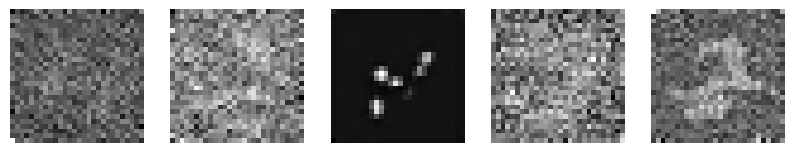

100%|██████████| 938/938 [02:14<00:00,  6.98it/s]


Epoch [2/25] - Loss: 0.0285


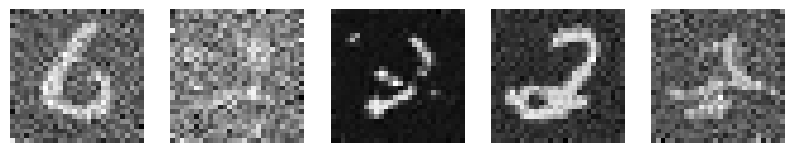

100%|██████████| 938/938 [02:17<00:00,  6.83it/s]


Epoch [3/25] - Loss: 0.0256


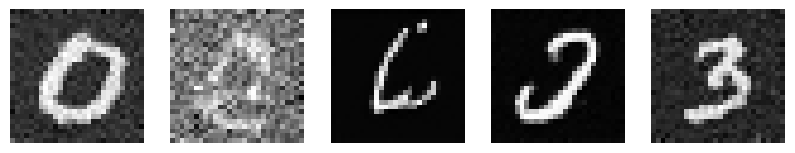

100%|██████████| 938/938 [02:15<00:00,  6.94it/s]


Epoch [4/25] - Loss: 0.0246


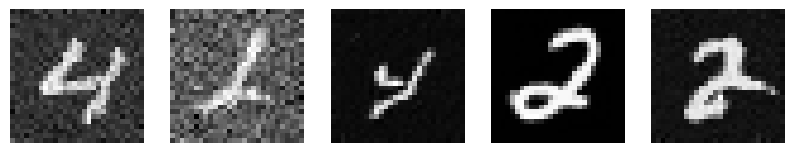

100%|██████████| 938/938 [02:16<00:00,  6.88it/s]


Epoch [5/25] - Loss: 0.0240


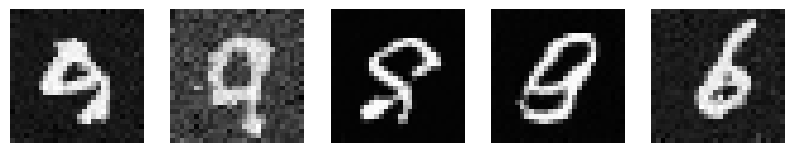

100%|██████████| 938/938 [02:15<00:00,  6.94it/s]


Epoch [6/25] - Loss: 0.0235


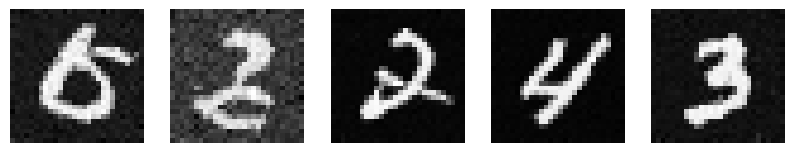

100%|██████████| 938/938 [02:16<00:00,  6.85it/s]


Epoch [7/25] - Loss: 0.0229


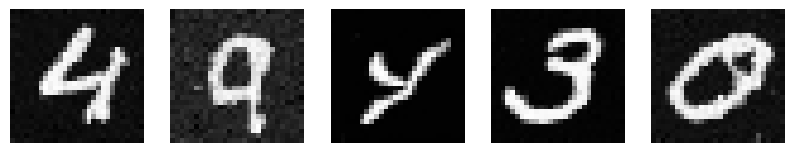

100%|██████████| 938/938 [02:15<00:00,  6.93it/s]


Epoch [8/25] - Loss: 0.0227


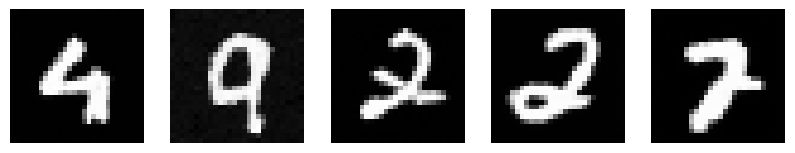

100%|██████████| 938/938 [02:16<00:00,  6.85it/s]


Epoch [9/25] - Loss: 0.0226


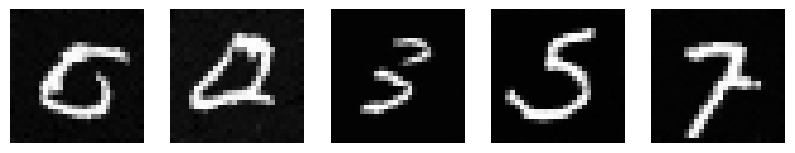

100%|██████████| 938/938 [02:14<00:00,  6.97it/s]


Epoch [10/25] - Loss: 0.0222


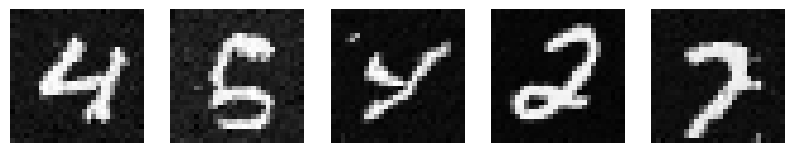

100%|██████████| 938/938 [02:15<00:00,  6.92it/s]


Epoch [11/25] - Loss: 0.0222


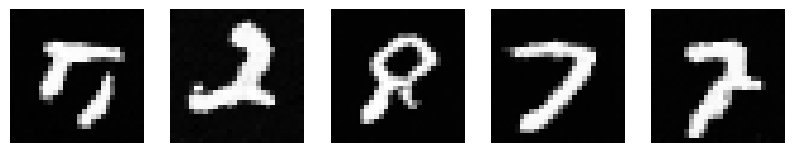

100%|██████████| 938/938 [02:13<00:00,  7.01it/s]


Epoch [12/25] - Loss: 0.0219


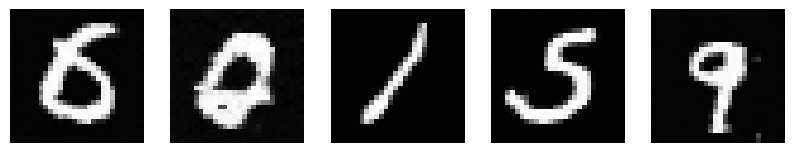

100%|██████████| 938/938 [02:13<00:00,  7.00it/s]


Epoch [13/25] - Loss: 0.0219


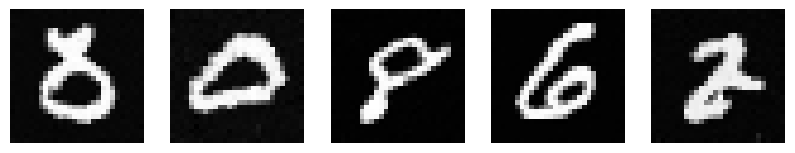

100%|██████████| 938/938 [02:13<00:00,  7.00it/s]


Epoch [14/25] - Loss: 0.0218


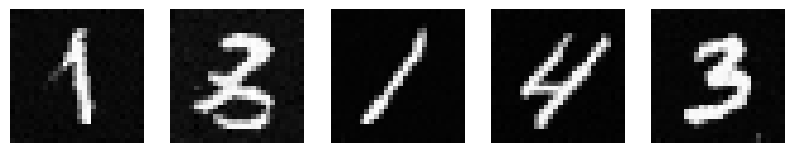

100%|██████████| 938/938 [02:13<00:00,  7.00it/s]


Epoch [15/25] - Loss: 0.0217


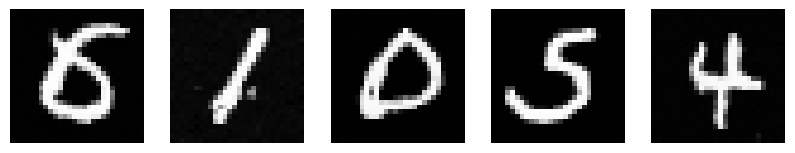

100%|██████████| 938/938 [02:14<00:00,  6.97it/s]


Epoch [16/25] - Loss: 0.0215


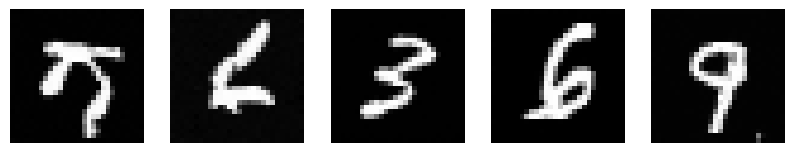

100%|██████████| 938/938 [02:14<00:00,  6.95it/s]


Epoch [17/25] - Loss: 0.0218


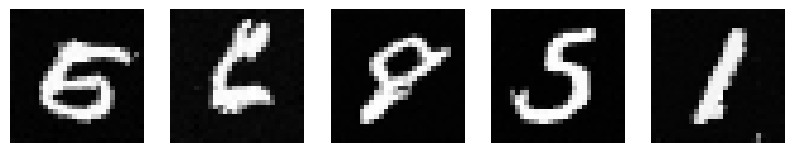

100%|██████████| 938/938 [02:14<00:00,  6.97it/s]


Epoch [18/25] - Loss: 0.0214


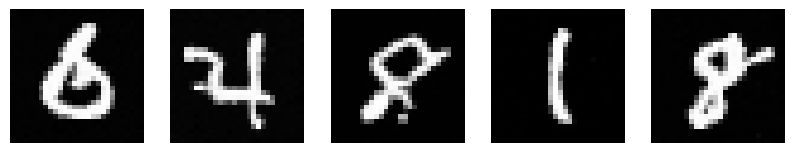

100%|██████████| 938/938 [02:14<00:00,  6.95it/s]


Epoch [19/25] - Loss: 0.0214


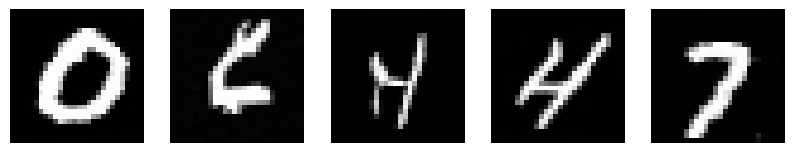

100%|██████████| 938/938 [02:15<00:00,  6.93it/s]


Epoch [20/25] - Loss: 0.0213


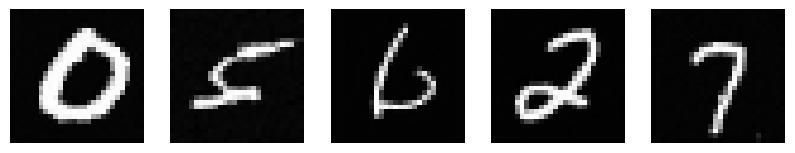

100%|██████████| 938/938 [02:14<00:00,  6.95it/s]


Epoch [21/25] - Loss: 0.0212


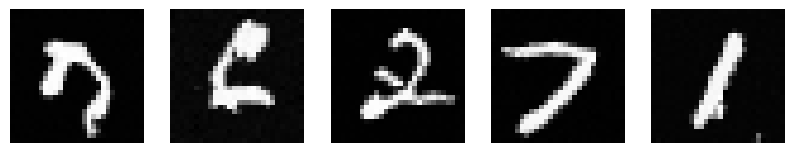

100%|██████████| 938/938 [02:14<00:00,  6.99it/s]


Epoch [22/25] - Loss: 0.0214


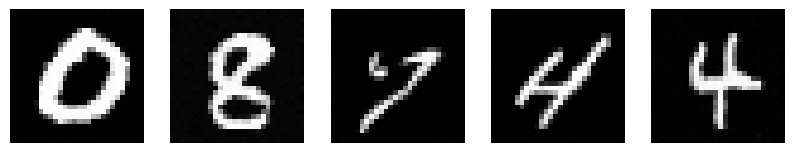

100%|██████████| 938/938 [02:13<00:00,  7.02it/s]


Epoch [23/25] - Loss: 0.0210


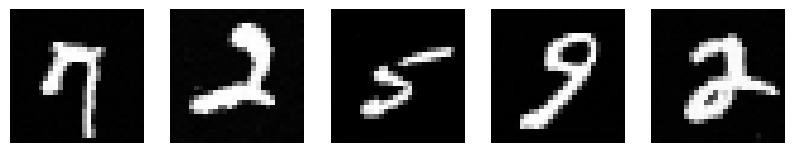

100%|██████████| 938/938 [02:13<00:00,  7.01it/s]


Epoch [24/25] - Loss: 0.0212


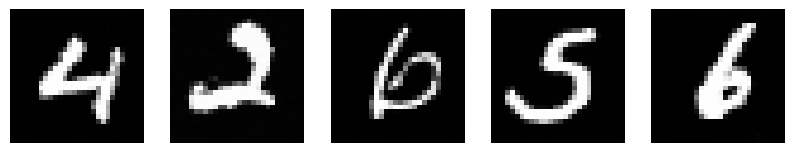

100%|██████████| 938/938 [02:14<00:00,  7.00it/s]


Epoch [25/25] - Loss: 0.0209


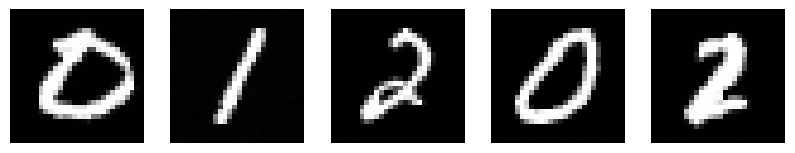

In [14]:
# Create the UNet model
model = create_unet()

# Train the diffusion mode
model, loss_histories = train_model(model)

Text(0.5, 1.0, 'Training Loss')

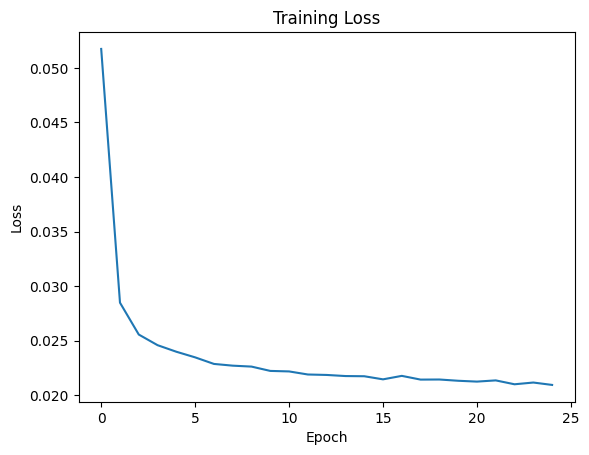

In [15]:
# Plot loss histories
plt.plot(loss_histories["mse"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

In [19]:
# Uncomment to download pretrained model
#model = diffusers.UNet2DModel.from_pretrained("harveymannering/mnist-ddpm").to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/973 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

# Inference

Now let try to generate some image. Firstly, we will generate with the standard sampling procedure described in Algorithm 2.

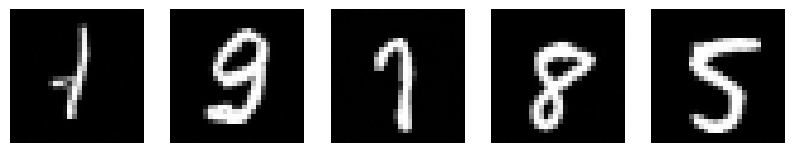

In [79]:
# Generate samples
noise = torch.randn(5, 1, 28, 28).to(device).float()
labels = torch.randint(10, (5,)).to(device)
samples = sample(noise, model, labels, total_steps=20)

# Plot samples
fig, axes = plt.subplots(1,5, figsize=(10,2))
for i, ax in enumerate(axes):
    ax.imshow(samples[i,0].cpu().numpy(), cmap="gray")
    ax.axis("off")
plt.show()


However, since we trained our model on both unconditional and conditional generation, we are able to use a technique called Classifier Free Guidance (CFG). When generating our samples this involve applying the following formula when predicting our noise:

$$\hat\epsilon = w D_{\theta}(x_t,t,y) + (1- w) D_{\theta}(x_t,t)$$

where $y$ is a condition (in our case that's a class label denoting the MNIST digit) and $w$ is a weight that controls the strength of our classifier free guidance.  This has two effects. The first is to increase the likelihood of the class $y$ and the second is to increase image quality. The downside is that diversity is decreased, but in practice, this method is widely used due to its ability to noticably increase image quality and controllability.

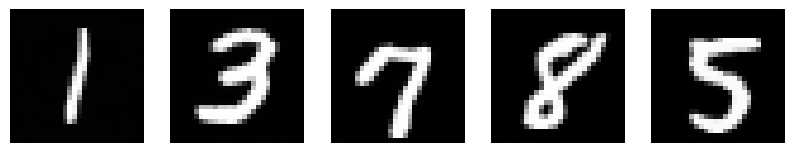

In [80]:
samples = sample(noise, model, labels, total_steps=20, w=3.0)

# Plot samples
fig, axes = plt.subplots(1,5, figsize=(10,2))
for i, ax in enumerate(axes):
    ax.imshow(samples[i,0].cpu().numpy(), cmap="gray")
    ax.axis("off")
plt.show()